In [1]:
import sys; sys.path.insert(0, "..")
from src.pipeline.orchestrator import ARGUSPipeline
from src.models.stage2_economics import calculate_economic_impact
pipeline = ARGUSPipeline()
print("ARGUS pipeline loaded ✓")

2026-04-03 17:05:06.327 | INFO     | src.data.gee:_init_gee:49 - GEE: initialised successfully
2026-04-03 17:05:08.504 | WARNING  | src.data.torchgeo_pipeline:<module>:29 - TorchGeo: not installed — using basic transforms
Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.
2026-04-03 17:05:12.408 | INFO     | src.pipeline.orchestrator:__init__:134 - ARGUSPipeline: initialising...
2026-04-03 17:05:14.565 | INFO     | src.models.stage1_sat:__init__:155 - PlumeSegmenter: ViT-384d | 22,330,065 params
2026-04-03 17:05:14.566 | WARNING  | src.models.stage1_sat:load_model:359 - PlumeSegmenter: no checkpoint at models\checkpoints\sat_model.pt — using random weights. Run scripts/train_stage1.py to train.
2026-04-03 17:05:14.570 | INFO     | src.models.stage2_pinn:__init__:120 - ConcentrationNet: 166,529 params
2026-04-03 17:05:14.572 | WARNING  | src.models.stage2_pinn:__init__:168 - PINNFluxEstima

ARGUS pipeline loaded ✓


In [2]:
result = pipeline.run(lat_min=37, lat_max=40, lon_min=55, lon_max=60)
print(f"Run ID: {result.run_id}")
print(f"Detections: {len(result.detections)}")
print(f"Super-emitters: {result.n_super_emitters}")
print(f"Total flux: {result.total_flux_kg_hr:.1f} kg/hr")

2026-04-03 17:05:15.424 | INFO     | src.pipeline.orchestrator:run:172 - ARGUSPipeline [RUN-138130D3]: bbox=(37.00,40.00,55.00,60.00)
2026-04-03 17:05:17.255 | INFO     | src.data.gee:_fetch_gee:137 - GEE TROPOMI: fetched (35, 56) grid | 2026-03-29 → 2026-04-03
2026-04-03 17:05:17.725 | ERROR    | src.data.gee:_fetch_gee:257 - GEE ERA5: failed (Empty date ranges not supported for the current operation.) — falling back to mock
2026-04-03 17:05:17.726 | INFO     | src.data.gee:_mock:270 - GEE ERA5: generated synthetic wind mock
2026-04-03 17:05:17.727 | INFO     | src.pipeline.orchestrator:run:191 - Wind: u=5.20 v=-1.80 m/s
2026-04-03 17:05:20.214 | INFO     | src.models.stage1_sat:extract_plume_detections:343 - PlumeSegmenter: 0 plumes detected (0 high-confidence)
2026-04-03 17:05:20.216 | INFO     | src.pipeline.orchestrator:run:233 - Stage 1: 0 plumes detected


Run ID: RUN-138130D3
Detections: 0
Super-emitters: 0
Total flux: 0.0 kg/hr


In [3]:
for det in result.detections[:3]:
    flux = det.get("flux_kg_hr", 0)
    econ = calculate_economic_impact(flux)
    print(econ.summary_line)
    for line in econ.detail_lines:
        print(" ", line)

2026-04-03 17:05:20.380 | INFO     | src.data.tropomi:_mock:133 - TROPOMI: generated synthetic mock dataset
2026-04-03 17:05:21.231 | INFO     | src.models.stage1_sat:__init__:155 - PlumeSegmenter: ViT-384d | 22,330,065 params
2026-04-03 17:05:21.233 | WARNING  | src.models.stage1_sat:load_model:359 - PlumeSegmenter: no checkpoint at models\checkpoints\sat_model.pt — using random weights. Run scripts/train_stage1.py to train.


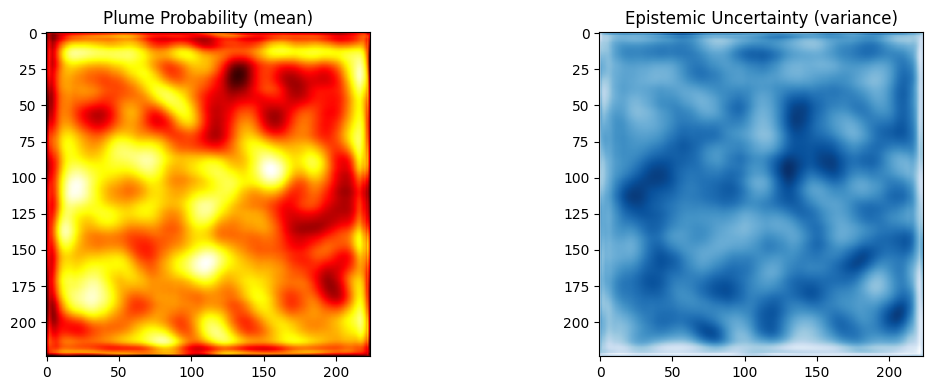

Uncertainty map saved ✓


In [4]:
import matplotlib.pyplot as plt
import torch
from src.data.tropomi import TROPOMIIngester
from src.models.stage1_sat import preprocess_tropomi, mc_predict, load_model

ds   = TROPOMIIngester._mock(37, 40, 55, 60)
t    = preprocess_tropomi(ds)
mdl  = load_model()
out  = mc_predict(mdl, t)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(out.mask_mean.squeeze(), cmap="hot")
axes[0].set_title("Plume Probability (mean)")
axes[1].imshow(out.mask_variance.squeeze(), cmap="Blues")
axes[1].set_title("Epistemic Uncertainty (variance)")
plt.tight_layout()
plt.savefig("uncertainty_map.png", dpi=150)
plt.show()
print("Uncertainty map saved ✓")

In [5]:
import requests
resp = requests.post("http://localhost:8000/api/v1/detect", json={
    "lat_min": 37, "lat_max": 40,
    "lon_min": 55, "lon_max": 60,
})
print(resp.json()["summary"])

{'n_detections': 1, 'n_super_emitters': 1, 'total_flux_kg_hr': 125440.0, 'total_co2e_kg_hr': 10035200.0, 'total_impact_usd': 0.0, 'total_impact_inr': 0.0, 'emit_validated': True, 'cloud_inpainted': False}
